## imports

In [1]:
from lora_config import *
from trainer import *
from inference import *
from lora_classes import *
from loss import *
import json
from dataclasses import asdict

print("configuration lora :")
print(json.dumps(asdict(lora_cfg), indent=2))
print("\ngroupes d'insectes :")
for grp in insect_cfg.groups:
    print(f"  • {grp}")

device : cpu
pytorch : 2.11.0+cpu
configuration lora :
{
  "rank": 8,
  "alpha": 16.0,
  "dropout": 0.05,
  "target_modules": [
    "Conv2d",
    "Linear"
  ],
  "min_weight_size": 16
}

groupes d'insectes :
  • hymenoptera


## LoRA

Pour une couche de poids $W_0 \in \mathbb{R}^{d_{out} \times d_{in}}$, on remplace la mise à jour par :

$$h = W_0 x + \underbrace{\frac{\alpha}{r} \cdot BA}_{\Delta W} x$$

avec $A \in \mathbb{R}^{r \times d_{in}}$, $B \in \mathbb{R}^{d_{out} \times r}$, $r \ll \min(d_{in}, d_{out})$.

In [2]:
lora_manager = LoRAWeightManager(train_cfg.save_dir)

## 3. Modèle YOLO-Pose + LoRA

WARNING no model scale passed. Assuming scale='n'.
WARNING no model scale passed. Assuming scale='n'.


2026-05-29 17:54:57,982 - INFO - YOLOPoseLoRA initialisé :
2026-05-29 17:54:57,983 - INFO -   • paramètres totaux   :    7,532,002
2026-05-29 17:54:57,984 - INFO -   • paramètres gelés    :    6,903,714
2026-05-29 17:54:57,985 - INFO -   • paramètres lora     :      628,288  (8.34% du total)
2026-05-29 17:54:57,985 - INFO -   • couches lora        : 147


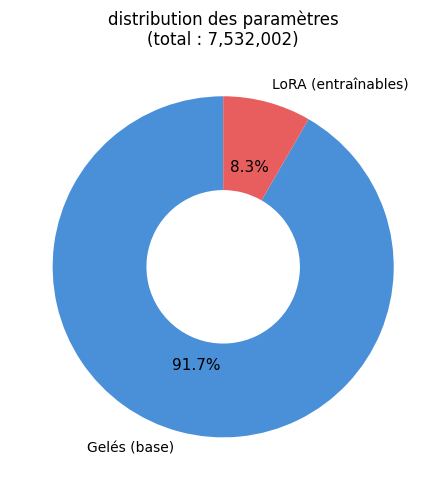


réduction : seuls 628,288 paramètres entraînés par groupe.


In [3]:
model = YOLOPoseLoRA(
    base_model_path = insect_cfg.base_model,
    lora_config     = lora_cfg,
).to(DEVICE)

stats  = count_parameters(model.backbone)
labels = ["Gelés (base)", "LoRA (entraînables)"]
sizes  = [stats["frozen"], stats["trainable"]]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%",
    colors=["#4A90D9", "#E85D5D"],
    startangle=90, wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title(f"distribution des paramètres\n(total : {stats['total']:,})", fontsize=12)
plt.tight_layout()
plt.show()
print(f"\nréduction : seuls {stats['trainable']:,} paramètres entraînés par groupe.")


## 4. Dataset — Format YOLO Pose

Format attendu : dossiers `images/` et `labels/` au format YOLO.
Chaque ligne de label :
```
class cx cy w h  kp1x kp1y kp1v  kp2x kp2y kp2v ...
```
(coordonnées normalisées, visibilité 0/1/2)

## 5. Fonctions de loss

Combinaison :
- **L_bbox** : CIoU loss (boîtes englobantes)
- **L_kp** : MSE pondéré par la visibilité des keypoints
- **L_reg** : régularisation L2 sur les poids LoRA

## 6. Boucle d'entraînement LoRA

In [4]:

trainer = LoRATrainer(model, lora_manager, train_cfg)
print("✓ LoRATrainer instancié")


✓ LoRATrainer instancié


## 7. Entraînement séquentiel sur tous les groupes

In [5]:
import pickle

# Tester le dataset
ds = InsectPoseDataset(insect_cfg.groups["hymenoptera"], "train", train_cfg.img_size, insect_cfg.num_keypoints)
try:
    pickle.dumps(ds)
    print("Dataset OK")
except Exception as e:
    print(f"Erreur dataset : {e}")

# Tester un sample
try:
    pickle.dumps(ds[0])
    print("Sample OK")
except Exception as e:
    print(f"Erreur sample : {e}")

2026-05-29 17:54:58,194 - INFO - dataset [train] : 153 images — Hymenoptera


Dataset OK
Sample OK


In [6]:
import traceback
import pickle

try:
    train_dl, val_dl = build_dataloaders("hymenoptera", insect_cfg.groups["hymenoptera"], train_cfg, insect_cfg)
    for batch in train_dl:
        break
except Exception as e:
    traceback.print_exc()

2026-05-29 17:54:58,347 - INFO - dataset [train] : 153 images — Hymenoptera
2026-05-29 17:54:58,350 - INFO - dataset [val] : 19 images — Hymenoptera
c:\Users\tombe\Documents\_MLE\CV-for-GRIT\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
all_histories = train_all_groups(
    model, trainer, insect_cfg, train_cfg,
    dry_run=False,
)

print("\ngroupes traités :", list(all_histories.keys()))


2026-05-29 17:54:59,667 - INFO - 
préparation du groupe : hymenoptera
2026-05-29 17:54:59,687 - INFO - dataset [train] : 153 images — Hymenoptera
2026-05-29 17:54:59,694 - INFO - dataset [val] : 19 images — Hymenoptera
2026-05-29 17:54:59,696 - INFO - 
2026-05-29 17:54:59,697 - INFO - entraînement groupe : HYMENOPTERA
2026-05-29 17:54:59,698 - INFO - ============================================================


tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)


2026-05-29 17:58:23,714 - INFO -   → groupe 'hymenoptera' sauvegardé : checkpoints\lora_hymenoptera.pt (628,288 params lora)
2026-05-29 17:58:23,715 - INFO -   epoch   1/30 | train=1749.0294 | val=275.5275 | lr=3.33e-04


tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)


2026-05-29 18:01:46,684 - INFO -   → groupe 'hymenoptera' sauvegardé : checkpoints\lora_hymenoptera.pt (628,288 params lora)


...

tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)


2026-05-29 18:12:20,346 - INFO -   → groupe 'hymenoptera' sauvegardé : checkpoints\lora_hymenoptera.pt (628,288 params lora)
2026-05-29 18:12:20,348 - INFO -   epoch   5/30 | train=411.1704 | val=105.0993 | lr=9.87e-04


tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(False)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
ten

2026-05-29 18:29:24,596 - INFO -   epoch  10/30 | train=nan | val=nan | lr=8.45e-04


tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)

## 8. Visualisation des courbes d'entraînement

In [ ]:
plot_training_curves(all_histories)


## 9. Analyse de la compression LoRA

Comparaison du coût de stockage : full fine-tuning vs LoRA.

In [ ]:
def analyse_compression(
    model: YOLOPoseLoRA,
    lora_config: LoRAConfig,
    n_groups: int = 5,
):
    """tableau et graphe comparatif full fine-tuning vs lora."""
    stats = count_parameters(model.backbone)
    total = stats["total"]
    lora_n = stats["trainable"]

    bytes_per_param    = 4
    full_mb_per_group  = total  * bytes_per_param / 1e6
    lora_mb_per_group  = lora_n * bytes_per_param / 1e6
    base_mb            = total  * bytes_per_param / 1e6

    print("\n" + "─" * 60)
    print(f"  paramètres backbone (gelés)   : {total:>14,}")
    print(f"  paramètres lora par groupe    : {lora_n:>14,}")
    print(f"  ratio de compression          : {total/lora_n:>14.1f}×")
    print(f"  mémoire backbone (mo)         : {base_mb:>14.2f}")
    print(f"  mémoire lora / groupe (mo)    : {lora_mb_per_group:>14.4f}")
    print("─" * 60)
    print(f"  stockage {n_groups} groupes — full ft  : {n_groups * full_mb_per_group:>10.2f} mo")
    print(f"  stockage {n_groups} groupes — lora     : {base_mb + n_groups * lora_mb_per_group:>10.2f} mo")
    print(f"  économie totale               : {(n_groups*full_mb_per_group) / (base_mb + n_groups*lora_mb_per_group):.1f}×")
    print("─" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    group_counts = range(1, n_groups + 1)
    full_storage = [g * full_mb_per_group for g in group_counts]
    lora_storage = [base_mb + g * lora_mb_per_group for g in group_counts]

    axes[0].plot(group_counts, full_storage, "o-", color="#E85D5D", lw=2, ms=7, label="full fine-tuning")
    axes[0].plot(group_counts, lora_storage, "s-", color="#4A90D9", lw=2, ms=7, label=f"lora (r={lora_config.rank})")
    axes[0].fill_between(group_counts, lora_storage, full_storage, alpha=0.15, color="#27AE60", label="économie")
    axes[0].set_xlabel("nombre de groupes d'insectes")
    axes[0].set_ylabel("stockage (mo)")
    axes[0].set_title("coût de stockage vs nombre de groupes")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    lora_state = LoRAWeightManager.extract_lora_state(model.backbone)
    if lora_state:
        type_counts = {"lora_A / down": 0, "lora_B / up": 0}
        for k, v in lora_state.items():
            if "lora_A" in k or "lora_down" in k:
                type_counts["lora_A / down"] += v.numel()
            else:
                type_counts["lora_B / up"] += v.numel()
        axes[1].bar(type_counts.keys(), type_counts.values(),
                    color=["#4A90D9", "#E8A030"], width=0.5)
        axes[1].set_ylabel("nombre de paramètres")
        axes[1].set_title("paramètres lora par type (un groupe)")
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
        axes[1].grid(True, axis="y", alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "lora non chargé", ha="center", va="center",
                     transform=axes[1].transAxes)

    plt.suptitle("analyse de compression lora", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


analyse_compression(model, lora_cfg, n_groups=len(insect_cfg.groups))


## 10. Inférence avec sélection du groupe

Point d'entrée à brancher avec le classifieur de groupe (implémentation future).

In [ ]:
from inference import InsectPosePredictor


predictor = InsectPosePredictor(model, lora_manager)

dummy_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
# results = predictor.predict(dummy_image, group="coleoptera")
# predictor.visualize(dummy_image, results)
print("(inférence commentée — décommenter avec vos données réelles)")


## 11. Analyse du rang optimal

Le rang `r` est le principal hyperparamètre LoRA. On évalue la qualité de la reconstruction pour différents rangs.

In [ ]:
def analyse_rank_sensitivity(
    model: YOLOPoseLoRA,
    ranks: List[int] = [2, 4, 8, 16, 32, 64],
):
    """
    mesure pour chaque rang r : nombre de paramètres lora et erreur
    de reconstruction par décomposition svd sur les couches du backbone.
    """
    stats_total = count_parameters(model.backbone)
    total_base  = stats_total["total"]

    weight_matrices = []
    for name, module in model.backbone.named_modules():
        if isinstance(module, LoRAConv2d):
            W    = module.base_layer.weight.detach()
            W_2d = W.view(W.shape[0], -1)
            if min(W_2d.shape) >= max(ranks):
                weight_matrices.append((name, W_2d))
        elif isinstance(module, LoRALinear):
            W = module.base_layer.weight.detach()
            if min(W.shape) >= max(ranks):
                weight_matrices.append((name, W))

    if not weight_matrices:
        print("aucune matrice compatible — simulation.")
        weight_matrices = [(f"layer_{i}", torch.randn(256, 128)) for i in range(5)]

    print(f"\nanalyse svd sur {len(weight_matrices)} matrices...")

    results = {}
    for r in ranks:
        errors, param_counts = [], []
        for name, W in weight_matrices:
            try:
                U, S, Vt = torch.linalg.svd(W, full_matrices=False)
                W_approx  = (U[:, :r] * S[:r]) @ Vt[:r, :]
                errors.append(((W - W_approx).norm() / W.norm()).item())
                param_counts.append(r * (W.shape[0] + W.shape[1]))
            except Exception:
                pass

        if errors:
            results[r] = {
                "mean_error":  np.mean(errors),
                "std_error":   np.std(errors),
                "lora_params": int(np.mean(param_counts)) * len(weight_matrices),
                "compression": total_base / max(int(np.mean(param_counts)) * len(weight_matrices), 1),
            }

    print(f"\n{'rang':>6} {'erreur moy.':>12} {'params lora':>14} {'compression':>12}")
    print("-" * 50)
    for r, s in results.items():
        print(f"  r={r:<4} {s['mean_error']:>11.4f} {s['lora_params']:>14,} {s['compression']:>11.1f}×")

    fig, ax1 = plt.subplots(figsize=(9, 5))
    r_vals = list(results.keys())
    errors = [results[r]["mean_error"]  for r in r_vals]
    stds   = [results[r]["std_error"]   for r in r_vals]
    params = [results[r]["lora_params"] for r in r_vals]

    ax1.errorbar(r_vals, errors, yerr=stds, fmt="o-", color="#E85D5D",
                 lw=2, ms=7, capsize=4, label="erreur de reconstruction (svd)")
    ax1.set_xlabel("rang r")
    ax1.set_ylabel("erreur relative (‖W - W_r‖ / ‖W‖)", color="#E85D5D")
    ax1.tick_params(axis="y", labelcolor="#E85D5D")
    ax1.set_xticks(r_vals)

    ax2 = ax1.twinx()
    ax2.bar(r_vals, params, alpha=0.3, color="#4A90D9", width=1.5, label="paramètres lora")
    ax2.set_ylabel("nombre de paramètres lora", color="#4A90D9")
    ax2.tick_params(axis="y", labelcolor="#4A90D9")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
    ax1.set_title("trade-off rang lora : précision vs paramètres", fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results


rank_analysis = analyse_rank_sensitivity(model)
